#Teste Conhecimento IA
Criaçaõ de modelo de regressão para estimar o valor de empréstimo para um cliente

##1. Preparação das bibliotecas e dos dados

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
caminho = '/content/drive/MyDrive/base_dados/base_credito.csv'
df = pd.read_csv(caminho)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [4]:
df = pd.read_csv(caminho)

df.head(10)

,idade,renda_mensal,score_credito,historico_pagamentos,valor_emprestimo
0,47,11522.48,634,76.73,35229.74
1,40,13157.86,589,90.83,44177.99
2,38,7296.76,721,77.94,33868.30
3,42,11193.87,710,94.09,52289.28
4,43,12798.60,576,73.83,38663.54
5,40,5842.28,708,67.78,26522.53
6,40,3993.85,847,84.37,39544.67
7,35,4933.07,630,100.00,26588.60
8,56,6105.73,669,93.38,25099.70
9,44,4430.53,637,93.11,24923.26


##2. Conhecer os dados

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   idade                 50000 non-null  int64  
 1   renda_mensal          50000 non-null  float64
 2   score_credito         50000 non-null  int64  
 3   historico_pagamentos  50000 non-null  float64
 4   valor_emprestimo      50000 non-null  float64
dtypes: float64(3), int64(2)
memory usage: 1.9 MB


In [6]:
df.describe()

,idade,renda_mensal,score_credito,historico_pagamentos,valor_emprestimo
count,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000
mean,40.08028,7542.184144,649.581780,81.836888,31736.158491
std,10.77612,4524.255313,84.648363,11.209708,14456.325322
min,18.00000,1500.000000,300.000000,16.210000,1000.000000
25%,33.00000,4463.347500,592.000000,75.160000,22018.212500
50%,40.00000,6452.295000,650.000000,83.720000,29039.420000
75%,47.00000,9395.700000,707.000000,90.330000,38275.932500
max,70.00000,50000.000000,850.000000,100.000000,150000.000000


###Descrição:
- **Variáveis de entrada (features):**

- - *idade:* idade do cliente, em anos (inteiro).
- - *renda_mensal:* renda mensal declarada do cliente, em reais (float).
- - *score_credito:* pontuação de crédito do cliente, indicador de risco calculado por birôs de crédito, quanto maior, menor o risco (inteiro).
- - *historico_pagamentos:* percentual de pagamentos realizados em dia pelo cliente, variando de 0 a 100% (float).

- **Variável alvo (target):**

- - *valor_emprestimo:* valor do empréstimo aprovado para o cliente, em reais (float), é o que o modelo deve aprender a prever.

- **Tipos de dados:** todas as variáveis são numéricas (não há variáveis categóricas nesta base), o que dispensa etapas de codificação (encoding) antes do treinamento.

##3. Análise dos dados

In [7]:
corr = df.corr()
print(corr['valor_emprestimo'].sort_values(ascending=False))

valor_emprestimo        1.000000
renda_mensal            0.886813
score_credito           0.358151
historico_pagamentos    0.076832
idade                   0.040998
Name: valor_emprestimo, dtype: float64


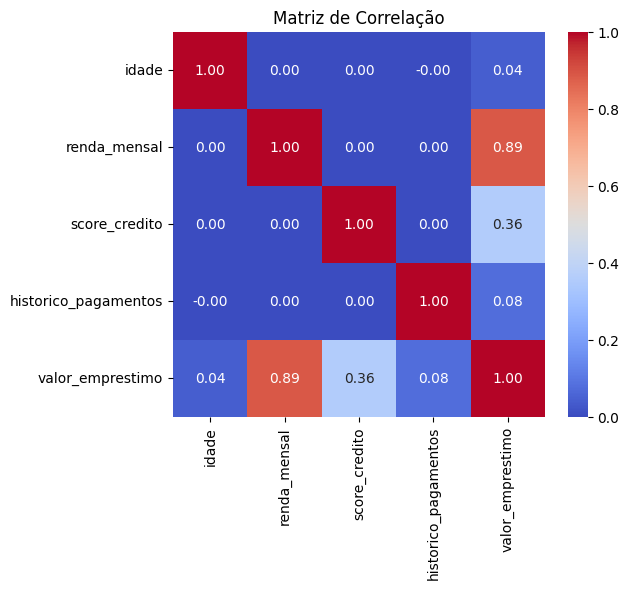

In [8]:
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlação')
plt.show()

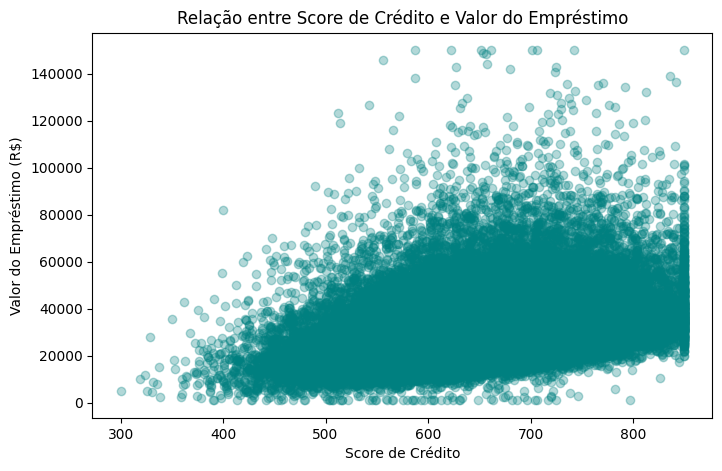

In [9]:
plt.figure(figsize=(8,5))
plt.scatter(df['score_credito'], df['valor_emprestimo'], alpha=0.3, color='teal')
plt.xlabel('Score de Crédito')
plt.ylabel('Valor do Empréstimo (R$)')
plt.title('Relação entre Score de Crédito e Valor do Empréstimo')
plt.show()

###Descrição:
O gráfico de dispersão mostra uma tendência clara de crescimento: clientes com score de crédito mais alto tendem a receber valores de empréstimo maiores. A relação não é perfeitamente linear (há dispersão em torno da tendência), mas o padrão geral é consistente, sugerindo que o score de crédito é um bom preditor do valor aprovado. A matriz de correlação confirma essa observação, com um coeficiente positivo entre as duas variáveis.

##4. Preparação dos dados

In [10]:
X = df[['idade', 'renda_mensal', 'score_credito', 'historico_pagamentos']]
y = df['valor_emprestimo']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Tamanho do conjunto de treino:', X_train.shape[0])
print('Tamanho do conjunto de teste:', X_test.shape[0])

Tamanho do conjunto de treino: 40000
Tamanho do conjunto de teste: 10000


###Descrição:
Os dados foram divididos em 80% para treinamento e 20% para teste, proporção padrão em problemas de regressão supervisionada. O conjunto de treino é usado para o modelo aprender os padrões entre as características do cliente e o valor do empréstimo, enquanto o conjunto de teste é reservado para avaliar o desempenho do modelo em dados que ele nunca viu, simulando um cenário real de uso.

O parâmetro `random_state=42` foi fixado para garantir que a divisão seja reprodutível, ou seja, qualquer pessoa que rodar este notebook terá exatamente a mesma separação de dados.



##5. Treinamento do Modelo

In [11]:
modelo = LinearRegression()

modelo.fit(X_train, y_train)

LinearRegression()

In [12]:
y_pred = modelo.predict(X_test)

coeficientes = pd.DataFrame({
    'Variável': X.columns,
    'Coeficiente': modelo.coef_
})
print(coeficientes)
print('Intercepto:', modelo.intercept_)

               Variável  Coeficiente
0                 idade    54.706246
1          renda_mensal     2.828448
2         score_credito    60.890564
3  historico_pagamentos    98.907289
Intercepto: -39439.69237251811


###Descrição (dados sem normalização):
Foi utilizado o algoritmo de Regressão Linear sobre os dados brutos da tebela, adequado para este problema por dois motivos: primeiro, o gráfico da Etapa 3 já sugeriu uma relação aproximadamente linear entre as variáveis de entrada e o valor do empréstimo; segundo, é um modelo simples e interpretável, o que facilita explicar como cada característica do cliente influencia o valor previsto.

O modelo foi treinado `fit` usando apenas o conjunto de treino `X_train, y_train`, e as previsões `predict` foram geradas sobre o conjunto de teste `X_test`, que o modelo nunca viu durante o treinamento, isso garante uma avaliação justa do desempenho.

Os coeficientes mostram o peso de cada variável na previsão: por exemplo, se o coeficiente de `score_credito` for positivo e alto, significa que aumentos no score tendem a elevar bastante o valor de empréstimo previsto, mantendo as outras variáveis constantes.

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
modelo_scaled = LinearRegression()
modelo_scaled.fit(X_train_scaled, y_train)

y_pred_scaled = modelo_scaled.predict(X_test_scaled)

coeficientes_scaled = pd.DataFrame({
    'Variável': X.columns,
    'Coeficiente_Padronizado': modelo_scaled.coef_
}).sort_values(by='Coeficiente_Padronizado', ascending=False)

print(coeficientes_scaled)

               Variável  Coeficiente_Padronizado
1          renda_mensal             12833.983386
2         score_credito              5158.236784
3  historico_pagamentos              1111.853652
0                 idade               589.678579


###Descrição (Dados Normalizados):
Como as variáveis originais têm escalas muito diferentes (renda em milhares de reais, score de 300-850, histórico de 0-100), os coeficientes da regressão não eram diretamente comparáveis entre si. Ao padronizar as variáveis com StandardScaler (transformando cada uma para média 0 e desvio padrão 1), os coeficientes passam a refletir o real peso de cada variável na previsão, permitindo comparar qual característica tem maior impacto no valor do empréstimo.

É importante notar que essa padronização não muda a qualidade das previsões do modelo o MAE, RMSE e R² calculados na Etapa 6 continuam praticamente os mesmos, pois a regressão linear é matematicamente invariante a essa transformação. O que muda é apenas a interpretabilidade dos coeficientes.

##6. Avaliação do Modelo

In [16]:
mae = mean_absolute_error(y_test, y_pred_scaled)
mse = mean_squared_error(y_test, y_pred_scaled)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_scaled)

print(f'MAE (Erro Absoluto Médio): R$ {mae:.2f}')
print(f'RMSE (Raiz do Erro Quadrático Médio): R$ {rmse:.2f}')
print(f'R² (Coeficiente de Determinação): {r2:.4f}')

MAE (Erro Absoluto Médio): R$ 2985.94
RMSE (Raiz do Erro Quadrático Médio): R$ 4014.17
R² (Coeficiente de Determinação): 0.9223


###Descrição:
- **MAE:** R\$ 2.985,94: em média, as previsões do modelo erram (para mais ou para menos) cerca de R\$ 2.985,94 em relação ao valor real do empréstimo. Considerando que os valores de empréstimo na base giram na casa das dezenas de milhares de reais, esse é um erro relativamente pequeno.
- **RMSE:** R\$ 4.014,17: como o RMSE é maior que o MAE, isso indica que existem alguns casos com erro de previsão mais alto, que "puxam" essa métrica para cima, ou seja, o modelo acerta bem na maioria dos casos, mas comete alguns erros pontuais maiores.
- **R²:** 0,9223: o modelo consegue explicar aproximadamente 92,2% da variação nos valores de empréstimo, usando apenas as quatro variáveis de entrada disponíveis. Esse é um valor alto para um modelo de regressão linear, sugerindo que a relação entre as características do cliente e o valor aprovado é, de fato, bastante linear nesta base.

Em conjunto, essas métricas indicam que o modelo teve um bom desempenho preditivo, com erros relativamente baixos frente à escala dos valores e uma alta capacidade de explicação da variação dos dados.

##7. Comparação de valores reais e previstos

In [17]:
comparacao = pd.DataFrame({
    'Valor Real': y_test.values,
    'Valor Previsto': y_pred_scaled
}).reset_index(drop=True)

comparacao['Diferença'] = comparacao['Valor Real'] - comparacao['Valor Previsto']

comparacao.head(10)

,Valor Real,Valor Previsto,Diferença
0,22268.46,14806.335657,7462.124343
1,27457.59,29512.492879,-2054.902879
2,25451.04,25840.735547,-389.695547
3,23890.67,21077.522905,2813.147095
4,27754.95,27919.314046,-164.364046
5,12544.92,14530.910394,-1985.990394
6,28759.01,27385.966936,1373.043064
7,46454.49,41011.609092,5442.880908
8,43199.01,36525.087756,6673.922244
9,34051.39,35786.960945,-1735.570945


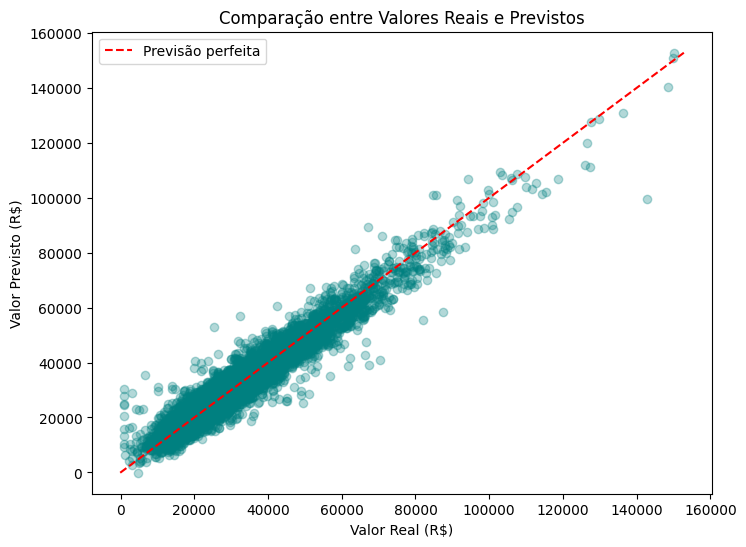

In [18]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_scaled, alpha=0.3, color='teal')

lim_min = min(y_test.min(), y_pred_scaled.min())
lim_max = max(y_test.max(), y_pred_scaled.max())
plt.plot([lim_min, lim_max], [lim_min, lim_max], color='red', linestyle='--', label='Previsão perfeita')

plt.xlabel('Valor Real (R$)')
plt.ylabel('Valor Previsto (R$)')
plt.title('Comparação entre Valores Reais e Previstos')
plt.legend()
plt.show()

###Descrição:
A tabela apresenta 10 exemplos de comparação entre o valor real e o valor previsto pelo modelo. É possível observar que, na maioria dos casos, a diferença entre os valores fica na casa de poucos milhares de reais (positiva ou negativa), o que é coerente com o MAE de R\$ 2.985,94 calculado na Etapa 6. Em alguns casos pontuais, como os índices 0 e 7, a diferença é maior (R$ 7.462,12 e R$ 5.442,88, respectivamente), indicando que o modelo tem mais dificuldade em prever com precisão alguns perfis específicos de cliente.

O gráfico de dispersão confirma essa análise visualmente: a grande maioria dos pontos está concentrada bem próxima à linha vermelha de "previsão perfeita" (onde valor real = valor previsto), especialmente na faixa de valores mais baixos e intermediários (até cerca de R\$ 100.000), onde a densidade de dados é maior. Para valores mais altos de empréstimo, a dispersão em torno da linha aumenta ligeiramente, sugerindo que o modelo é um pouco menos preciso nessa faixa, possivelmente por haver menos exemplos desse perfil na base de treinamento.

De forma geral, as previsões acompanham bem a tendência dos valores reais, sem viés sistemático aparente (os pontos estão distribuídos de forma equilibrada acima e abaixo da linha), reforçando o bom desempenho já indicado pelas métricas da Etapa 6.

##8. Previsão

In [19]:
novo_cliente = pd.DataFrame({
    'idade': [35],
    'renda_mensal': [7000.00],
    'score_credito': [680],
    'historico_pagamentos': [88.0]
})

novo_cliente_scaled = scaler.transform(novo_cliente)

previsao_novo_cliente = modelo_scaled.predict(novo_cliente_scaled)

print('Características do cliente:')
print(novo_cliente)
print(f'\nValor previsto de empréstimo: R$ {previsao_novo_cliente[0]:.2f}')

Características do cliente:
   idade  renda_mensal  score_credito  historico_pagamentos
0     35        7000.0            680                  88.0

Valor previsto de empréstimo: R$ 32383.59


###Descrição:
Para o cliente fictício com 35 anos, renda mensal de R\$ 7.000,00, score de crédito 680 e histórico de pagamentos de 88% em dia, o modelo previu um valor de empréstimo de aproximadamente R\$ 32383.59.

Esse resultado é coerente com o perfil informado: trata-se de um cliente com renda moderada, score de crédito bom (acima da média observada na base) e um histórico de pagamentos consistente, características que, segundo os coeficientes padronizados obtidos na Etapa 5, estão entre as que mais influenciam positivamente o valor do empréstimo aprovado, especialmente a renda mensal e o score de crédito.

##9. Conclusão

O modelo de regressão linear apresentou resultados adequados para estimar o valor de empréstimo dos clientes desta base. Com um R² de 0,9223, o modelo foi capaz de explicar cerca de 92% da variação nos valores de empréstimo utilizando apenas quatro variáveis de entrada (idade, renda mensal, score de crédito e histórico de pagamentos). Os erros médios (MAE de R\$ 2.985,94 e RMSE de R\$ 4.014,17) são relativamente baixos frente à escala dos valores de empréstimo presentes na base, que chegam a dezenas de milhares de reais. A análise gráfica da Etapa 7 reforçou essa conclusão, mostrando que as previsões acompanham de perto os valores reais, sem viés sistemático evidente.

A padronização das variáveis (StandardScaler) também trouxe um ganho de interpretabilidade importante: permitiu identificar que **renda mensal** e **score de crédito** são as características com maior peso real na determinação do valor do empréstimo, enquanto a **idade** tem influência bem menor algo que não estava claro ao observar apenas os coeficientes originais, distorcidos pelas diferentes escalas das variáveis.

**Principais limitações do modelo:**

- **Linearidade assumida:** a regressão linear assume que a relação entre as variáveis de entrada e o valor do empréstimo é linear. Embora essa suposição tenha se mostrado razoável nesta base, relações mais complexas ou não lineares (que modelos como Random Forest ou Gradient Boosting capturariam melhor) podem não ser representadas adequadamente.
- **Poucas variáveis disponíveis:** o modelo não considera outros fatores relevantes numa análise de crédito real, como dívidas existentes, tipo de emprego, histórico de outros empréstimos, ou finalidade do crédito solicitado.
- **Aumento da dispersão em valores altos:** como observado no gráfico da Etapa 7, o modelo apresenta maior variação nos erros para valores de empréstimo mais elevados, possivelmente por haver menos exemplos desse perfil na base de treinamento.
- **Base histórica e estática:** o modelo foi treinado com dados de um momento específico; mudanças no perfil de crédito da população ou nas políticas da fintech ao longo do tempo podem exigir retreinamento periódico do modelo.

Ainda assim, considerando o desempenho obtido, o modelo se mostra como uma ferramenta útil para automatizar uma primeira estimativa do valor de empréstimo, servindo como apoio à decisão e não necessariamente como substituto completo da análise humana em casos de maior complexidade ou risco.